# Gaussian Processes Practice

## Playing with a bivariate Gaussian Distribution

In [344]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

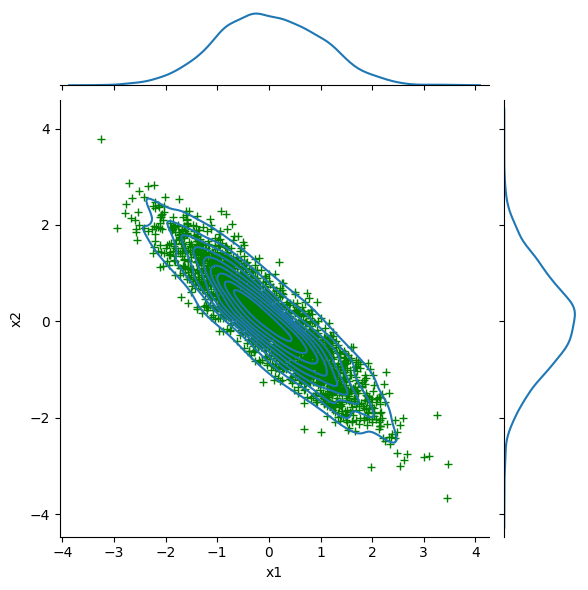

In [345]:
mean, cov = [0., 0.], [(1., -0.9), (-0.9, 1.)]
data = np.random.multivariate_normal(mean, cov, 2500)
df = pd.DataFrame(data, columns=["x1", "x2"])
g = sns.jointplot(x='x1', y='x2', data=df, kind='kde')

#(sns.jointplot("x1", "x2", data=df).plot_joint(sns.kdeplot))

g.plot_joint(plt.scatter, c="g", s=30, linewidth=1, marker="+")

#g.ax_joint.collections[0].set_alpha(0)
#g.set_axis_labels("<img src="/tex/8c76e0c69c5596634f9abb693bbf9438.svg?invert_in_darkmode&sanitize=true" align=middle width=17.614197149999992pt height=21.18721440000001pt/>", "<img src="/tex/1533fefb8348ed2119c7920bf5d7a8a5.svg?invert_in_darkmode&sanitize=true" align=middle width=17.614197149999992pt height=21.18721440000001pt/>");

plt.show()

## Simple example

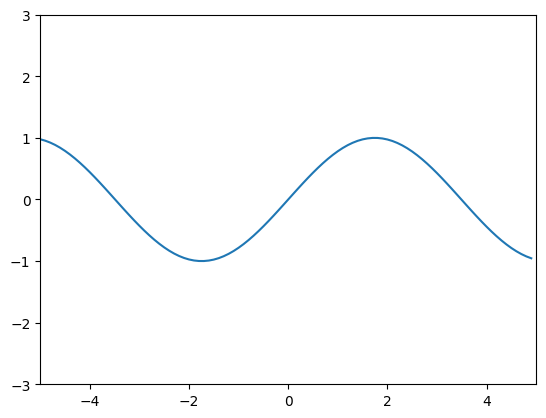

In [346]:
# The true function that we are trying to approximate
def f(x):
    return np.sin(0.9 * x).flatten()

# Domain
x = np.arange(-5, 5, 0.1)

plt.plot(x, f(x))
plt.axis([-5, 5, -3, 3])
plt.show()

In [347]:
# DEFINE THE KERNEL 
# The kernel governs the correlation between the functions
def kernel(a, b, l=0.25, sigma=0.1):
    '''Gaussian kernel'''
    sqdist = np.sum(a**2, axis=1).reshape(-1,1) + np.sum(b**2, 1) - 2*np.dot(a,b.T)
    return sigma * np.exp(-sqdist/(2 * l))

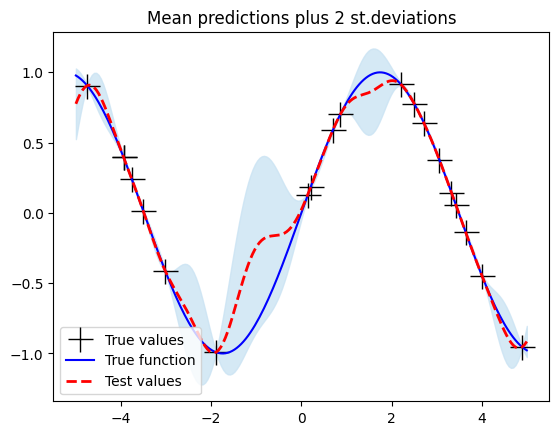

In [348]:
# Sample some input points and noisy version of the function at these points
N = 20      # Number of training points
n = 200     # Number of test points
s = 0.00005 # Noise variance

X = np.random.uniform(-5, 5, size=(N,1))
y = f(X) + s*np.random.rand(N)

K = kernel(X, X)
L = np.linalg.cholesky(K + s*np.eye(N))

# Points to predict at
Xtest = np.linspace(-5, 5, n).reshape(-1,1)

# Compute mean at test points
Lk = np.linalg.solve(L, kernel(X, Xtest))
mu = np.dot(Lk.T, np.linalg.solve(L, y))

# Compute the variance at our test points
K_ = kernel(Xtest, Xtest)
s2 = np.diag(K_) - np.sum(Lk**2, axis=0)
s = np.sqrt(s2)

# PLOTS:
plt.figure(1)
plt.clf()
plt.plot(X, y, 'k+', ms=18, label='True values')
plt.plot(Xtest, f(Xtest), 'b-', label='True function')
plt.gca().fill_between(Xtest.flat, mu-2*s, mu+2*s, color="#CAE3F3C7")
plt.plot(Xtest, mu, 'r--', lw=2, label = 'Test values')
#plt.savefig('predictive.png', bbox_inches='tight', dpi=300)
plt.title('Mean predictions plus 2 st.deviations')
plt.legend()
plt.show()
#plt.axis([-5, 5, -3, 3])

<Figure size 640x480 with 0 Axes>

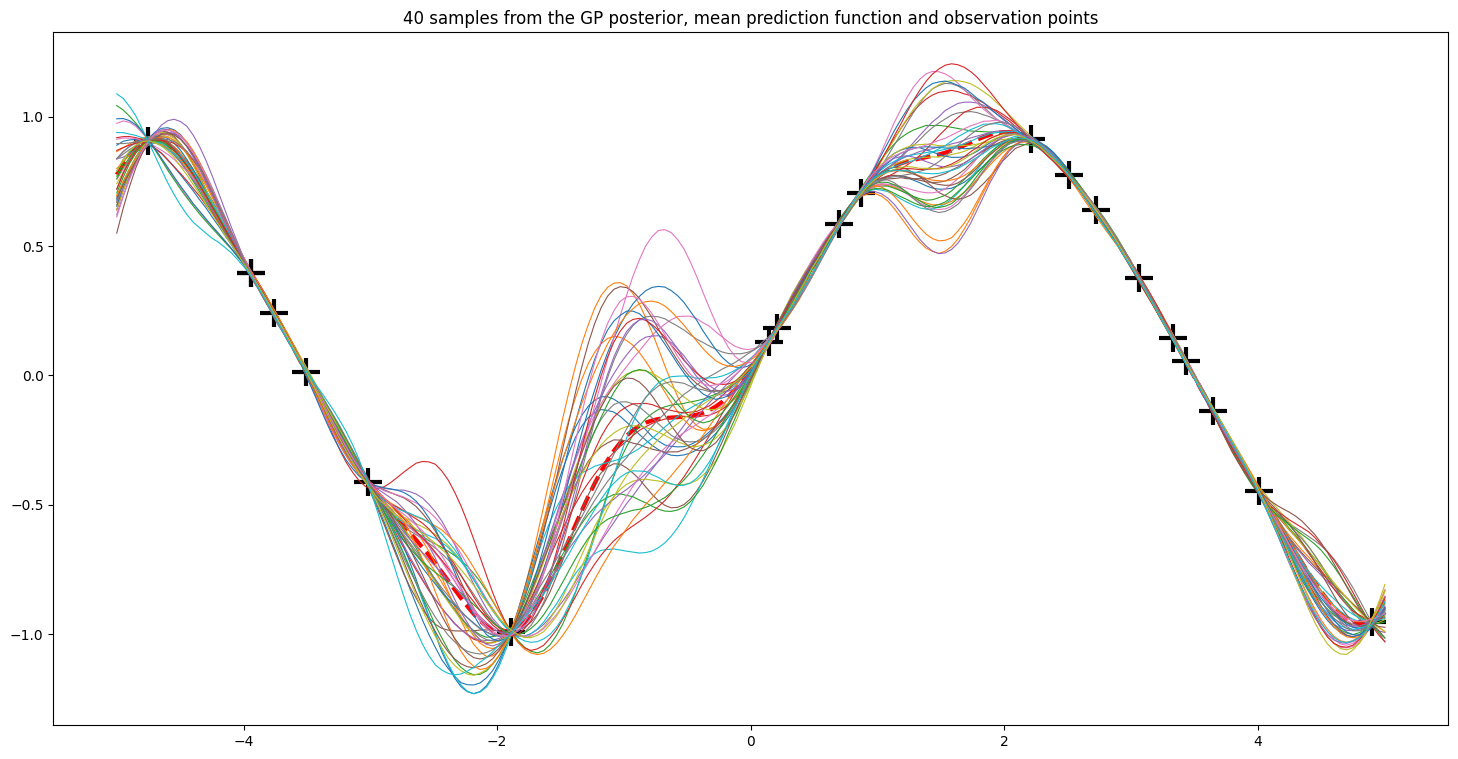

In [349]:
# Draw samples from the posterior at our test points
L = np.linalg.cholesky(K_ + 1e-6*np.eye(n) - np.dot(Lk.T, Lk))
f_post = mu.reshape(-1,1) + np.dot(L, np.random.normal(size=(n,40)))  # size=(n, m), m shown how many posterior  
plt.figure(3)
plt.clf()
plt.figure(figsize=(18,9))
plt.plot(X, y, 'k+', markersize=20, markeredgewidth=3)
plt.plot(Xtest, mu, 'r--', linewidth=3)
plt.plot(Xtest, f_post, linewidth=0.8)
plt.title('40 samples from the GP posterior, mean prediction function and observation points')
plt.show();

## Kernels practice
Here several types of kernels along with the properties are presented. The source material for this part are the following links:

- https://www.cs.toronto.edu/~duvenaud/cookbook/
- https://www.youtube.com/watch?v=UBDgSHPxVME

### Radial Basis Function (RBF)

Also known as Gaussian kernel, this kernel highly correlates inputs that are close to eachother:

$$
k_{\mathrm{RBF}}(x_i,x_j) = \sigma_f^2\mathrm{exp(-\frac{(x_i-x_j)^2}{2l^2})}
$$

In [350]:
def kernel_RBF(a, b, l=0.25, sigma=0.1):
    '''Gaussian kernel'''
    sqdist = np.sum(a**2, axis=1).reshape(-1,1) + np.sum(b**2, 1) - 2*np.dot(a,b.T)
    return sigma * np.exp(-sqdist/(2 * l))

Both `l` and `sigma` are hyperparemters. `l` controls the correlation lenght

Hyperparameter l: Controls the correlation length. It controls controls how far away the inputs should be to be considered similar.


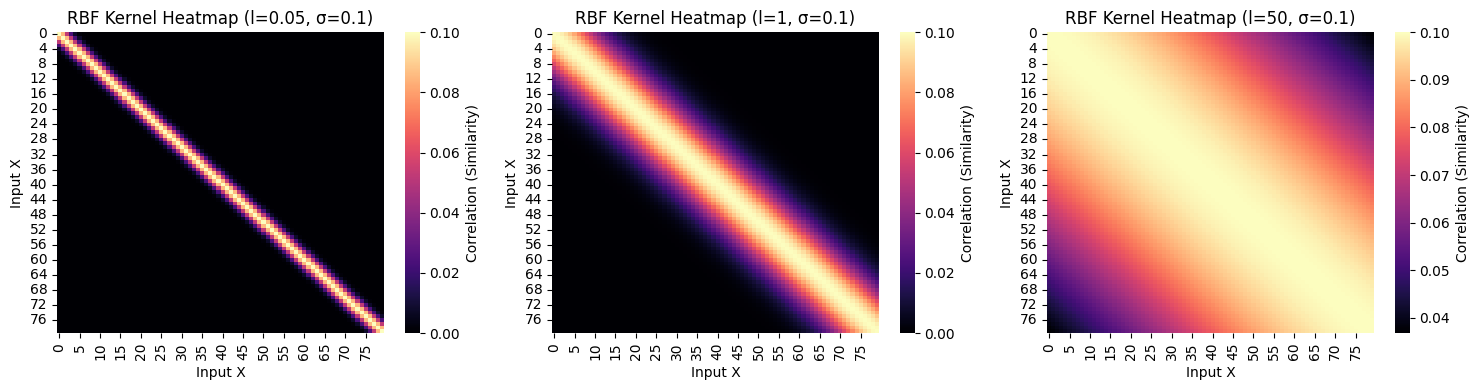

In [351]:
# Create input points
X = np.linspace(0, 10, 80).reshape(-1, 1)

# Compute kernel matrix (correlation between all pairs)
l_values = [0.05, 1, 50]
sigma = 0.1

print("Hyperparameter l: Controls the correlation length. It controls controls how far away the inputs should be to be considered similar.")

# Create figure with three subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot heatmaps for each l value
for idx, l in enumerate(l_values):
    # Compute kernel matrix
    K = kernel_RBF(X, X, l=l, sigma=sigma)
    
    # Plot heatmap on the corresponding subplot
    im = sns.heatmap(K,
                     cmap='magma',
                     cbar_kws={'label': 'Correlation (Similarity)'},
                     ax=axes[idx])
    
    axes[idx].set_title(f'RBF Kernel Heatmap (l={l}, σ={sigma})')
    axes[idx].set_xlabel('Input X')
    axes[idx].set_ylabel('Input X')

plt.tight_layout()
plt.show()


When using a RBF kernel to sample functions through a Gaussian Process, having different values of `l` is reflected in the smoothness of the functions. Lower `l` yields wiggly functions, while higher `l` values yield smooth and slowly varying functions

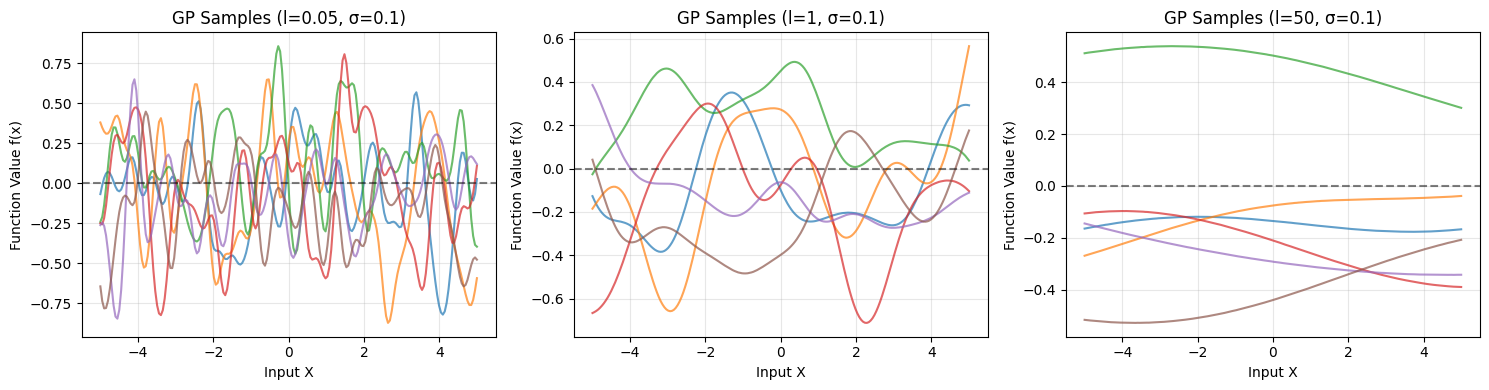

In [352]:
# Create test points for function sampling
X_test = np.linspace(-5, 5, 200).reshape(-1, 1)

# Number of functions to sample
n_samples = 6

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, l in enumerate(l_values):
    # Compute kernel matrix for test points
    K = kernel_RBF(X_test, X_test, l=l, sigma=sigma)
    
    # Add small noise to diagonal for numerical stability
    K += 1e-8 * np.eye(len(X_test))
    
    # Sample from multivariate normal distribution
    # Mean is zero (standard GP prior)
    mean = np.zeros(len(X_test))
    
    # Generate random samples
    np.random.seed(42)  # For reproducibility
    samples = np.random.multivariate_normal(mean, K, size=n_samples)
    
    # Plot samples
    for i in range(n_samples):
        axes[idx].plot(X_test.flatten(), samples[i], alpha=0.7, linewidth=1.5)
    
    axes[idx].set_title(f'GP Samples (l={l}, σ={sigma})')
    axes[idx].set_xlabel('Input X')
    axes[idx].set_ylabel('Function Value f(x)')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].axhline(y=0, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

On the other hand, the `sigma` hyperparameter controls the correlation strength between the inputs. When sampling functions from a GP with different `sigma` values, we see that `sigma` directly controls the vertical span of the sampled functions.

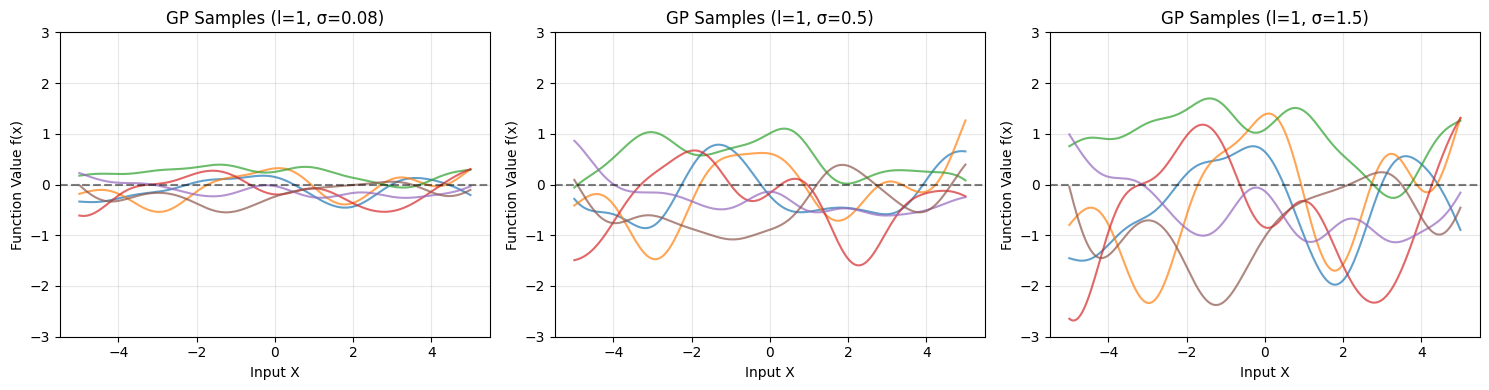

In [353]:
# Create test points for function sampling
X_test = np.linspace(-5, 5, 200).reshape(-1, 1)

# Number of functions to sample
n_samples = 6

# Sigma values
sigma_values = [0.08, 0.5, 1.5]
l = 1

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, sigma in enumerate(sigma_values):
    # Compute kernel matrix for test points
    K = kernel_RBF(X_test, X_test, l=l, sigma=sigma)
    
    # Add small noise to diagonal for numerical stability
    K += 1e-8 * np.eye(len(X_test))
    
    # Sample from multivariate normal distribution
    # Mean is zero (standard GP prior)
    mean = np.zeros(len(X_test))
    
    # Generate random samples
    np.random.seed(42)  # For reproducibility
    samples = np.random.multivariate_normal(mean, K, size=n_samples)
    
    # Plot samples
    for i in range(n_samples):
        axes[idx].plot(X_test.flatten(), samples[i], alpha=0.7, linewidth=1.5)
    
    axes[idx].set_title(f'GP Samples (l={l}, σ={sigma})')
    axes[idx].set_xlabel('Input X')
    axes[idx].set_ylabel('Function Value f(x)')
    axes[idx].set_ylim(-3, 3)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].axhline(y=0, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### ***<p style="text-align:center;">**Intuitively, a GP will sample function with nearby $y$'s for $x$'x deemed similar by the kernel.**</p>***

### Linear Kernel (1D)

The linear kernel is defined as follows:

$$
k_{\mathrm{linear}}(x_i,x_j) = vx_ix_j
$$

In [354]:
def kernel_linear1D(a, b, v=0.5):
    '''Linear Kernel'''
    return v * np.dot(a, b.T)

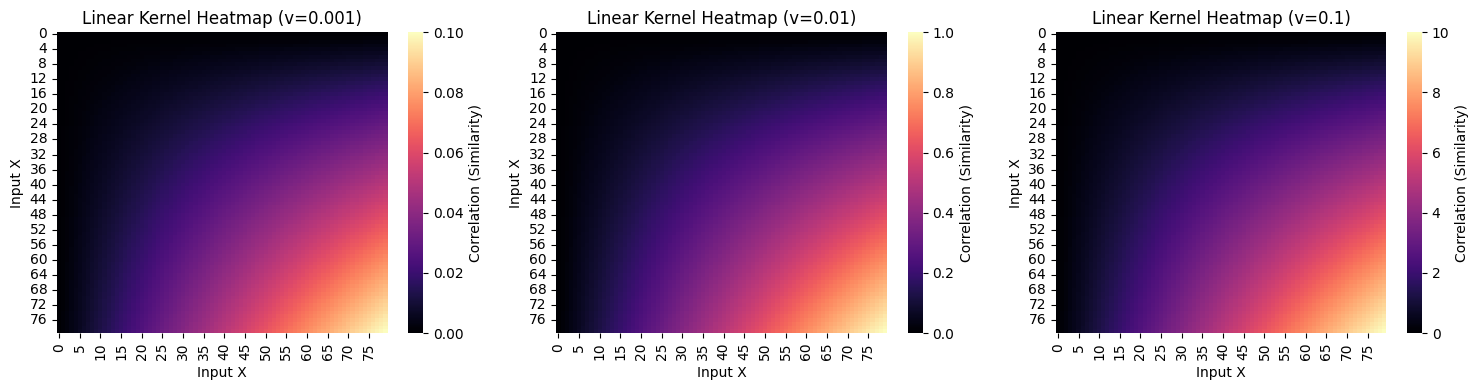

In [355]:
# Create input points
X = np.linspace(0, 10, 80).reshape(-1, 1)

# Compute kernel matrix (correlation between all pairs)
v_values = [0.001, 0.01, 0.1]

# Create figure with three subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot heatmaps for each l value
for idx, v in enumerate(v_values):
    # Compute kernel matrix
    K = kernel_linear1D(X, X, v=v)
    
    # Plot heatmap on the corresponding subplot
    im = sns.heatmap(K,
                     cmap='magma',
                     cbar_kws={'label': 'Correlation (Similarity)'},
                     ax=axes[idx])
    
    axes[idx].set_title(f'Linear Kernel Heatmap (v={v})')
    axes[idx].set_xlabel('Input X')
    axes[idx].set_ylabel('Input X')

plt.tight_layout()
plt.show()

The linear kernel constrains the space of sampled functions into the linear space (e.g. only linear functions are sampled). The hyperparameter `v` controls the slope of the sampled linear functions 

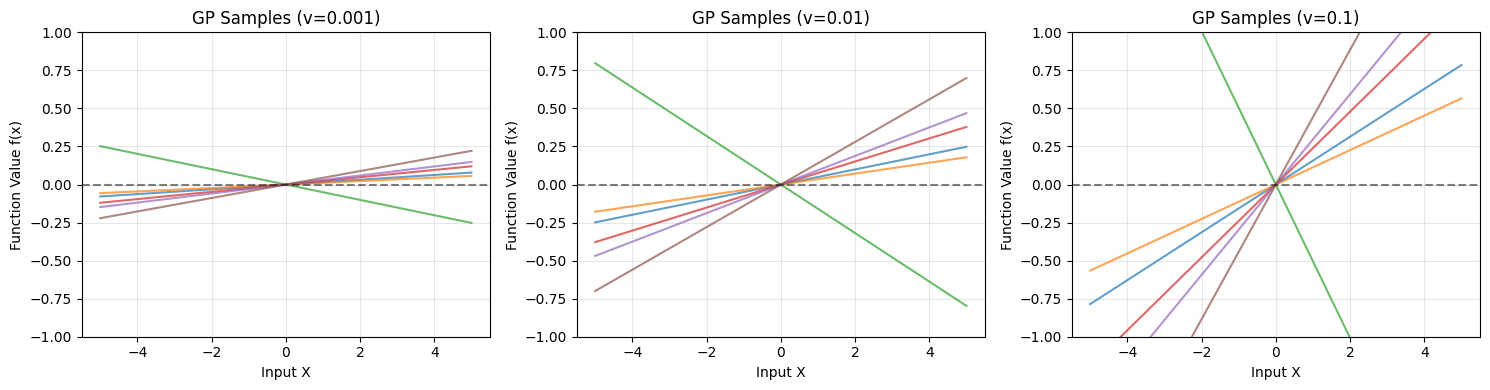

In [356]:
# Create test points for function sampling
X_test = np.linspace(-5, 5, 200).reshape(-1, 1)

# Number of functions to sample
n_samples = 6

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, v in enumerate(v_values):
    # Compute kernel matrix for test points
    K = kernel_linear1D(X_test, X_test, v=v)
    
    # Add small noise to diagonal for numerical stability
    K += 1e-8 * np.eye(len(X_test))
    
    # Sample from multivariate normal distribution
    # Mean is zero (standard GP prior)
    mean = np.zeros(len(X_test))
    
    # Generate random samples
    np.random.seed(42)  # For reproducibility
    samples = np.random.multivariate_normal(mean, K, size=n_samples)
    
    # Plot samples
    for i in range(n_samples):
        axes[idx].plot(X_test.flatten(), samples[i], alpha=0.7, linewidth=1.5)
    
    axes[idx].set_title(f'GP Samples (v={v})')
    axes[idx].set_xlabel('Input X')
    axes[idx].set_ylabel('Function Value f(x)')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylim(-1, 1)
    axes[idx].axhline(y=0, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Periodic Kernel
The Periodic kernel is defined as:

$$
k_p(x_i,x_j) = \sigma^2 \mathrm{exp}(-\frac{2}{l^2}\mathrm{sin}(\frac{\pi |x_i - x_j|}{p}))
$$

In [357]:
def kernel_periodic(a, b, l=0.5, p=0.5, sigma = 1):
    '''Periodic kernel'''
    return sigma * np.exp(-2/l * np.sin(np.pi/ p * np.abs(a-b.T)))

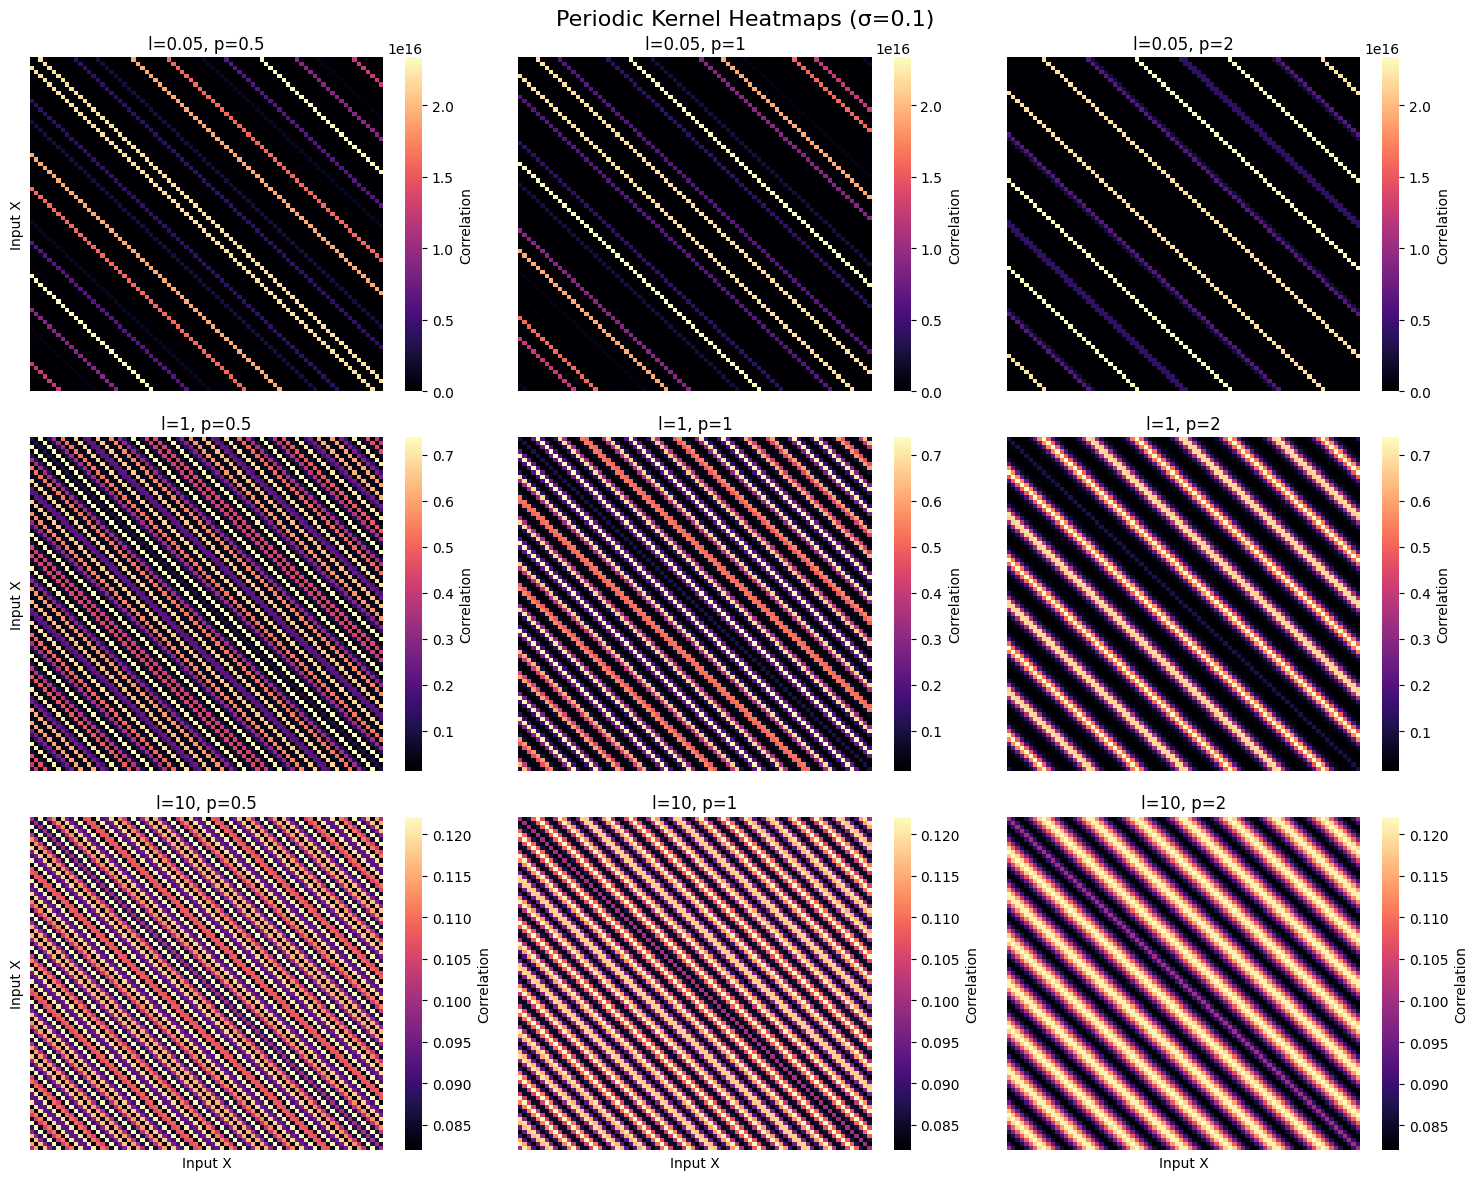

In [358]:
# Create input points
X = np.linspace(-15, 15, 80).reshape(-1, 1)

# Define parameter grids
l_values = [0.05, 1, 10]
p_values = [0.5, 1, 2]
sigma = 0.1

# Create figure with 3x3 subplots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

# Plot heatmaps for each combination of l and p
for i, l in enumerate(l_values):
    for j, p in enumerate(p_values):
        # Compute kernel matrix
        K = kernel_periodic(X, X, l=l, p=p, sigma=sigma)
        
        # Plot heatmap on the corresponding subplot
        sns.heatmap(K,
                    cmap='magma',
                    cbar_kws={'label': 'Correlation'},
                    ax=axes[i, j],
                    xticklabels=False,
                    yticklabels=False)
        
        axes[i, j].set_title(f'l={l}, p={p}')
        
        # Add labels only for outer plots
        if j == 0:
            axes[i, j].set_ylabel('Input X')
        if i == 2:
            axes[i, j].set_xlabel('Input X')

plt.suptitle(f'Periodic Kernel Heatmaps (σ={sigma})', fontsize=16)
plt.tight_layout()
plt.show()

- The `p` hyperparameter determines the distance between repetitions of the samples functions (the period)
- The `l` hyperparameter determines the lengthscale function in the same way as in the RBF kernel

/tmp/ipykernel_2209513/418024766.py:20: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples = np.random.multivariate_normal(mean, K, size=n_samples)


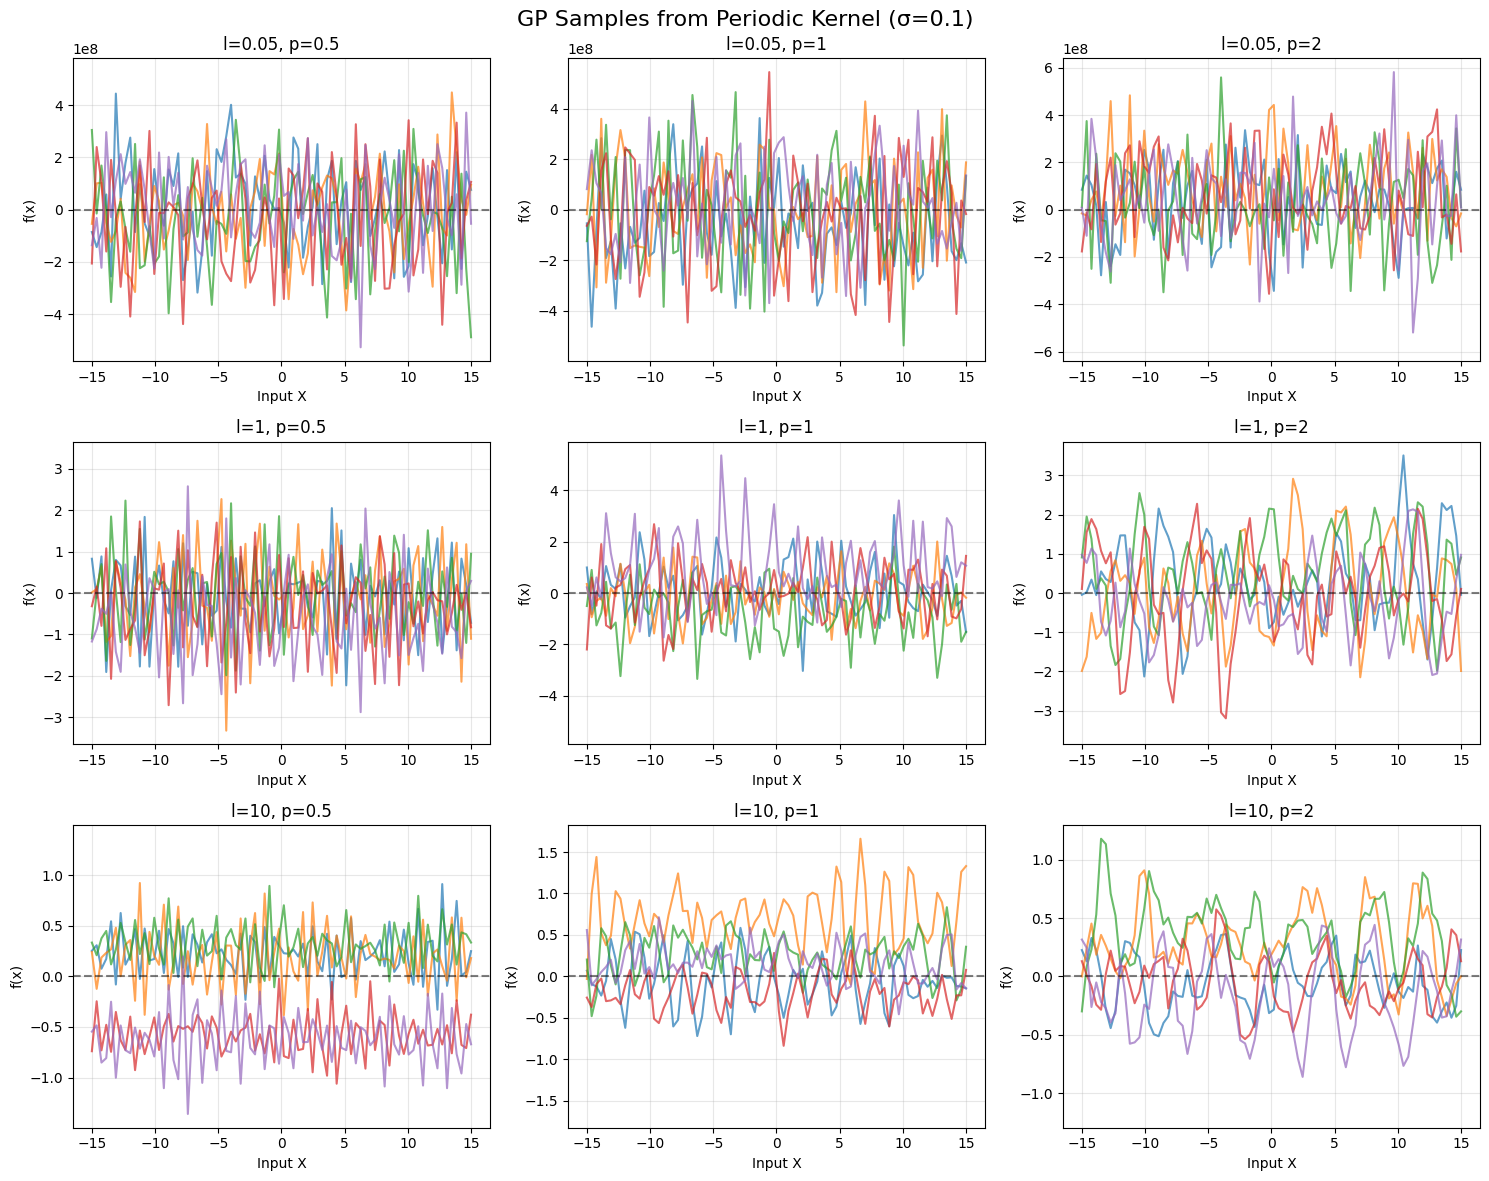

In [359]:
n_samples = 5  # Number of functions to sample per subplot

# Create figure with 3x3 subplots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

# Set random seed for reproducibility
np.random.seed(42)

# Sample functions for each combination of l and p
for i, l in enumerate(l_values):
    for j, p in enumerate(p_values):
        # Compute kernel matrix
        K = kernel_periodic(X, X, l=l, p=p, sigma=sigma)
        
        # Add small noise for numerical stability
        K += 1e-8 * np.eye(len(X))
        
        # Sample from GP prior (zero mean)
        mean = np.zeros(len(X))
        samples = np.random.multivariate_normal(mean, K, size=n_samples)
        
        # Plot sampled functions
        for k in range(n_samples):
            axes[i, j].plot(X.flatten(), samples[k], alpha=0.7, linewidth=1.5)
        
        axes[i, j].set_title(f'l={l}, p={p}')
        axes[i, j].set_xlabel('Input X')
        axes[i, j].set_ylabel('f(x)')
        axes[i, j].grid(True, alpha=0.3)
        axes[i, j].axhline(y=0, color='black', linestyle='--', alpha=0.5)
        
        # Set y-axis limits for better visualization
        y_max = max(0.5, np.max(np.abs(samples)) * 1.1)
        axes[i, j].set_ylim(-y_max, y_max)
        
        # Add labels only for outer plots
        if j == 0:
            axes[i, j].set_ylabel('f(x)')
        if i == 2:
            axes[i, j].set_xlabel('Input X')

plt.suptitle(f'GP Samples from Periodic Kernel (σ={sigma})', fontsize=16)
plt.tight_layout()
plt.show()

### Combining kernels

Kernels can be combined to produce special types of functions. For example, we could combine a linear kernel with a RBF kernel in the following way:

$$
k_1(x_i,x_j) = k_{\mathrm{RBF}}(x_i,x_j) + k_{\mathrm{linear}}(x_i,x_j)
$$

In [360]:
def kernel_1(a, b, l=1, sigma=0.1, v=0.01):
    return kernel_RBF(a, b, l, sigma) + kernel_linear1D(a, b, v)

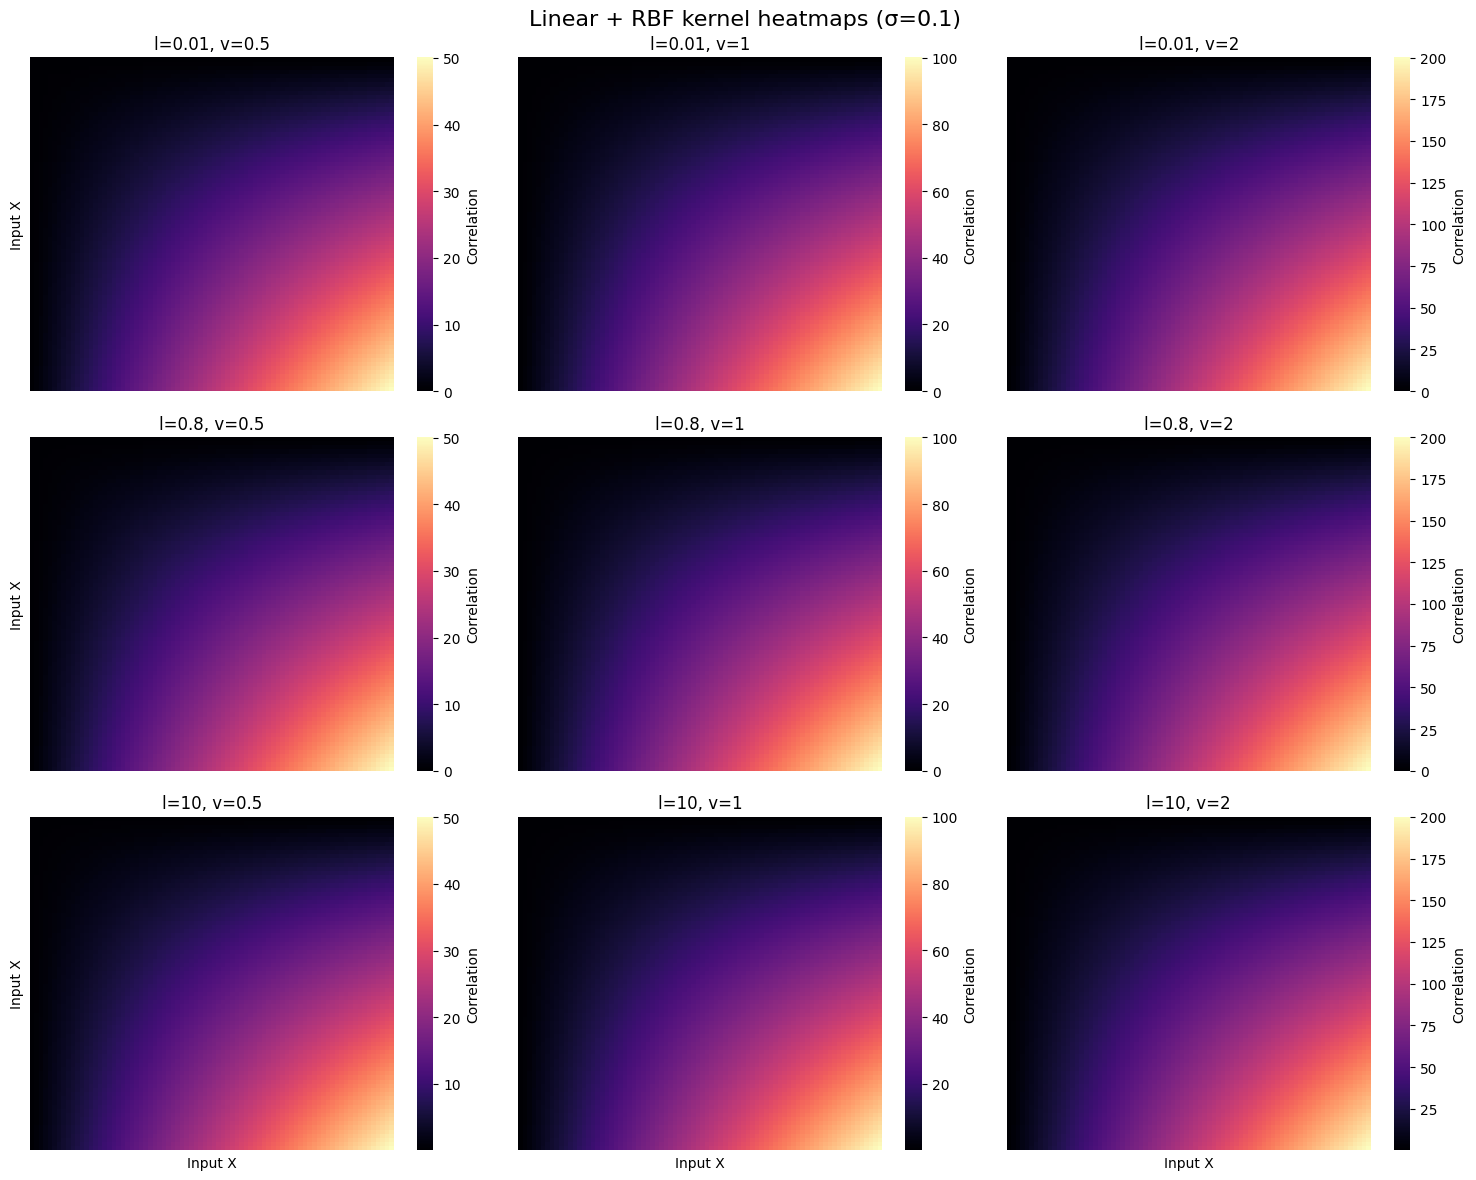

In [361]:
# Create input points
X = np.linspace(0, 10, 80).reshape(-1, 1)

# Define parameter grids
l_values = [0.01, 0.8, 10]
v_values = [0.5, 1, 2]
sigma = 0.1

# Create figure with 3x3 subplots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

# Plot heatmaps for each combination of l and p
for i, l in enumerate(l_values):
    for j, v in enumerate(v_values):
        # Compute kernel matrix
        K = kernel_1(X, X, l=l, v=v, sigma=sigma)
        
        # Plot heatmap on the corresponding subplot
        sns.heatmap(K,
                    cmap='magma',
                    cbar_kws={'label': 'Correlation'},
                    ax=axes[i, j],
                    xticklabels=False,
                    yticklabels=False)
        
        axes[i, j].set_title(f'l={l}, v={v}')
        
        # Add labels only for outer plots
        if j == 0:
            axes[i, j].set_ylabel('Input X')
        if i == 2:
            axes[i, j].set_xlabel('Input X')

plt.suptitle(f'Linear + RBF kernel heatmaps (σ={sigma})', fontsize=16)
plt.tight_layout()
plt.show()

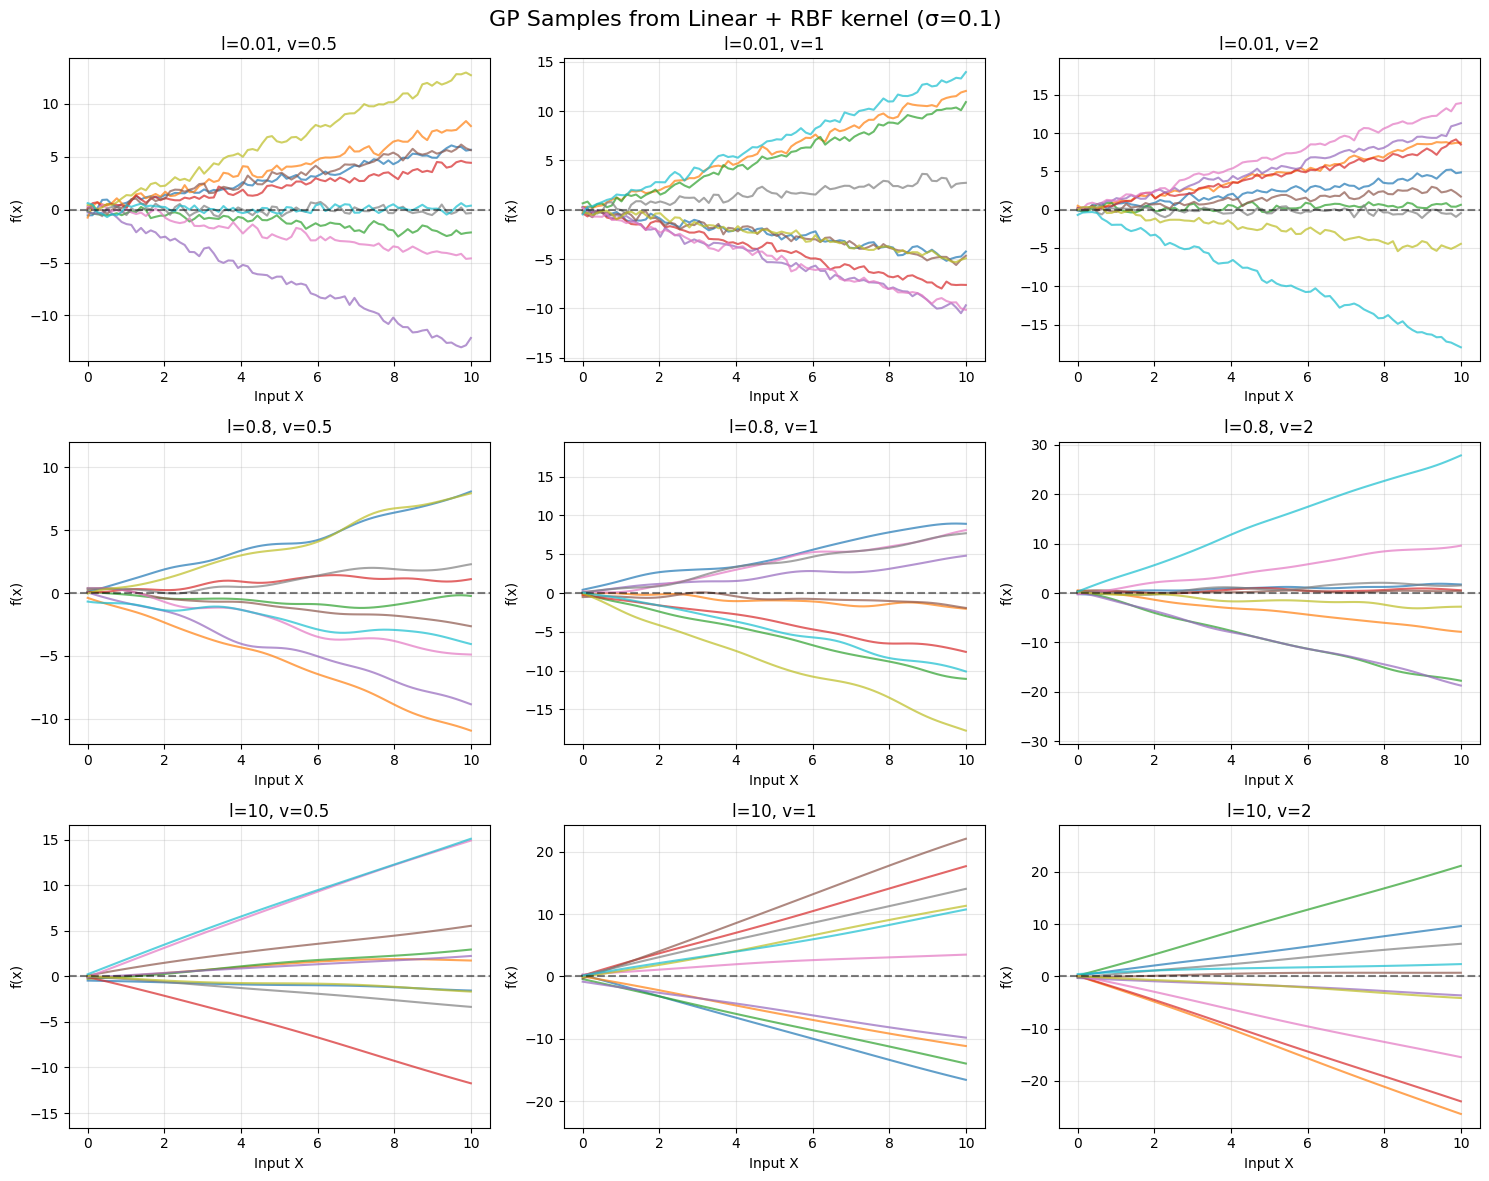

In [362]:
n_samples = 10  # Number of functions to sample per subplot

# Create figure with 3x3 subplots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

# Sample functions for each combination of l and p
for i, l in enumerate(l_values):
    for j, v in enumerate(v_values):
        # Compute kernel matrix
        K = kernel_1(X, X, l=l, v=v, sigma=sigma)
        
        # Add small noise for numerical stability
        K += 1e-8 * np.eye(len(X))
        
        # Sample from GP prior (zero mean)
        mean = np.zeros(len(X))
        samples = np.random.multivariate_normal(mean, K, size=n_samples)
        
        # Plot sampled functions
        for k in range(n_samples):
            axes[i, j].plot(X.flatten(), samples[k], alpha=0.7, linewidth=1.5)
        
        axes[i, j].set_title(f'l={l}, v={v}')
        axes[i, j].set_xlabel('Input X')
        axes[i, j].set_ylabel('f(x)')
        axes[i, j].grid(True, alpha=0.3)
        axes[i, j].axhline(y=0, color='black', linestyle='--', alpha=0.5)
        
        # Set y-axis limits for better visualization
        y_max = max(0.5, np.max(np.abs(samples)) * 1.1)
        axes[i, j].set_ylim(-y_max, y_max)
        
        # Add labels only for outer plots
        if j == 0:
            axes[i, j].set_ylabel('f(x)')
        if i == 2:
            axes[i, j].set_xlabel('Input X')

plt.suptitle(f'GP Samples from Linear + RBF kernel (σ={sigma})', fontsize=16)
plt.tight_layout()
plt.show()